# 02 — Clustering : segmentation des clients (J4–J5)

**Objectif :** regrouper les clients en segments homogènes, comprendre qui ils sont, puis réutiliser le segment (`cluster`) comme variable pour prédire le churn (J7).

**Règles respectées dans ce notebook**
- `Churn` n'est **jamais** utilisé pour construire les clusters. On l'utilise seulement *après coup*, pour lire les profils.
- Le preprocessor et K-Means sont ajustés (`fit`) sur le **train uniquement**. Le test reçoit ses clusters via `predict`, sans refit.

**Plan :** préparation → choix de k (Elbow + Silhouette) → K-Means → Agglomerative (et DBSCAN testé) → évaluation → PCA → profils → application au test → sauvegarde.

## 1. Imports et configuration

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))          # pour importer src/ depuis notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

from src.preprocessing import (prepare, load_data, train_test, build_preprocessor,
                               RANDOM_STATE, TARGET)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Préparation des données (sans `Churn`)

On refait le même split que dans `src/preprocessing.py` (`random_state` identique, donc mêmes clients dans train et test). Le preprocessor est ajusté sur le train, puis appliqué au train et au test.

Pour le clustering on garde les **32 colonnes** produites par le preprocessor : numériques standardisées (important, car K-Means repose sur des distances), one-hot et binaires.

In [2]:
df = prepare(load_data())
X_train, X_test, y_train, y_test = train_test(df)      # split stratifié, avant tout fit

pre = build_preprocessor().fit(X_train)                # fit sur le train uniquement
Z_train = pre.transform(X_train)
Z_test  = pre.transform(X_test)

assert TARGET not in Z_train.columns and TARGET not in Z_test.columns   # Churn absent du clustering
print("Z_train :", Z_train.shape, "| Z_test :", Z_test.shape)
Z_train.describe().loc[["mean", "std"], ["tenure", "MonthlyCharges", "n_services"]].round(2)

Z_train : (5634, 32) | Z_test : (1409, 32)


,tenure,MonthlyCharges,n_services
mean,-0.0,-0.0,-0.0
std,1.0,1.0,1.0


## 3. K-Means : choix du nombre de clusters

Deux outils :
- **Elbow** : l'inertie (somme des distances au centre) baisse toujours quand k augmente. On cherche le "coude" où le gain devient faible.
- **Silhouette** : mesure, entre -1 et 1, si chaque client est plus proche de son cluster que des autres. Plus c'est haut, mieux c'est.

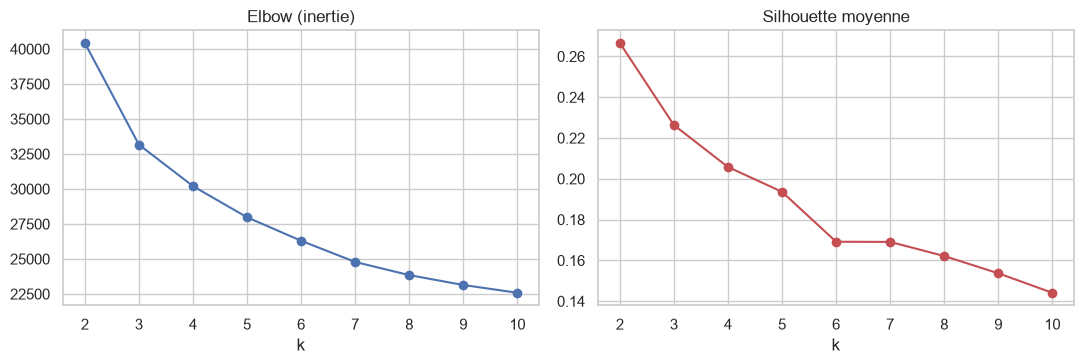

,inertie,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,40430.813,0.267,1.453,2585.109
3,33169.927,0.226,1.544,2191.527
4,30204.636,0.206,1.786,1788.405
5,27978.660,0.194,1.693,1559.725
6,26302.374,0.169,1.777,1398.799
7,24786.448,0.169,1.758,1294.095
8,23848.115,0.162,1.841,1184.286
9,23141.016,0.154,1.920,1089.209
10,22585.278,0.144,1.944,1007.212


In [3]:
ks = range(2, 11)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z_train)
    rows.append({"k": k, "inertie": km.inertia_,
                 "silhouette": silhouette_score(Z_train, km.labels_),
                 "davies_bouldin": davies_bouldin_score(Z_train, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(Z_train, km.labels_)})
scores = pd.DataFrame(rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(scores.index, scores["inertie"], "o-"); axes[0].set_title("Elbow (inertie)")
axes[1].plot(scores.index, scores["silhouette"], "o-", color="#C44E52"); axes[1].set_title("Silhouette moyenne")
for ax in axes: ax.set_xlabel("k")
plt.tight_layout(); plt.show()
scores.round(3)

**Lecture :**
- **Elbow** : la courbe décroît régulièrement, sans coude net. Le gain ralentit dès k = 3 ou 4 (la baisse d'inertie passe d'environ 7 300 entre k = 2 et 3 à environ 3 000 entre k = 3 et 4, puis 2 200 entre k = 4 et 5).
- **Silhouette** : maximale à k = 2 (≈ 0,27), puis elle baisse. Les valeurs restent faibles (< 0,3) : les groupes se **chevauchent**, ce qui est normal pour des clients décrits surtout par des variables oui/non.

**Choix : k = 4.**
k = 2 est le meilleur score mais trop grossier pour de la segmentation métier (il sépare presque seulement "gros" et "petits" clients). À k = 4 on obtient des segments très lisibles, avec des taux de churn nettement différents (voir section 8), et la silhouette ne s'effondre pas (≈ 0,21). C'est un compromis assumé entre score et utilité.

## 4. K-Means final (k = 4)

In [4]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Z_train)
labels_km = kmeans.labels_
pd.Series(labels_km).value_counts().sort_index().rename("effectif").to_frame()

,effectif
0,1586
1,1309
2,1241
3,1498


## 5. Deuxième algorithme : Agglomerative (et DBSCAN testé)

**Agglomerative (Ward)** : part de chaque client isolé et fusionne progressivement les groupes les plus proches. On le compare à K-Means avec le même k.

**DBSCAN** : forme des groupes par densité et marque comme "bruit" les points isolés. On teste quelques valeurs de `eps` pour voir s'il est adapté ici.

In [5]:
agglo = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(Z_train)
labels_ag = agglo.labels_

# DBSCAN : quelques valeurs de eps (min_samples = 10)
db_rows = []
for eps in [1.5, 2, 2.5, 3, 4]:
    lab = DBSCAN(eps=eps, min_samples=10).fit(Z_train).labels_
    db_rows.append({"eps": eps, "n_clusters": len(set(lab) - {-1}), "% bruit": round((lab == -1).mean() * 100, 1)})
pd.DataFrame(db_rows).set_index("eps")

,n_clusters,% bruit
eps,,
1.5,5,43.3
2.0,5,11.3
2.5,1,0.0
3.0,1,0.0
4.0,1,0.0


**Lecture DBSCAN :** pour `eps` petit, plus de 40 % des clients sont classés en "bruit" ; à `eps = 2`, un seul groupe contient presque tous les clients (~4950) et les autres sont minuscules (moins de 20 clients) ; dès `eps = 2,5`, tout fusionne en un seul groupe. Le passage de "trop fragmenté" à "un seul bloc" est brutal : avec 32 colonnes dont beaucoup de binaires, les densités sont peu contrastées, donc DBSCAN n'est pas adapté ici. On retient **K-Means** (modèle principal) et **Agglomerative** (comparaison), ce qui satisfait la consigne "DBSCAN ou Agglomerative".

## 6. Évaluation des clusters

Trois métriques internes (elles n'utilisent pas `Churn`) :
- **Silhouette** (↑ mieux) : cohésion et séparation.
- **Davies-Bouldin** (↓ mieux) : rapport entre dispersion interne et distance entre clusters.
- **Calinski-Harabasz** (↑ mieux) : rapport variance inter / intra.

On ajoute l'**ARI** (Adjusted Rand Index) entre les deux partitions : 1 = identiques, 0 = sans rapport.

In [6]:
def evaluate(Z, labels):
    return {"silhouette": silhouette_score(Z, labels),
            "davies_bouldin": davies_bouldin_score(Z, labels),
            "calinski_harabasz": calinski_harabasz_score(Z, labels)}

comparison = pd.DataFrame({"K-Means": evaluate(Z_train, labels_km),
                           "Agglomerative": evaluate(Z_train, labels_ag)}).T
display(comparison.round(3))
print("ARI K-Means vs Agglomerative :", round(adjusted_rand_score(labels_km, labels_ag), 3))

,silhouette,davies_bouldin,calinski_harabasz
K-Means,0.206,1.786,1788.405
Agglomerative,0.201,1.824,1594.888


ARI K-Means vs Agglomerative : 0.608


**Lecture :** les deux méthodes ont des scores proches, avec un léger avantage pour **K-Means** sur les trois métriques. L'ARI (≈ 0,6) montre qu'elles retrouvent en grande partie les mêmes groupes. La silhouette autour de 0,2 confirme une structure **réelle mais peu tranchée** : les clusters sont des tendances, pas des frontières nettes.
**Décision :** on garde K-Means (k = 4), qui permet en plus d'attribuer un cluster à un nouveau client avec `predict` (utile pour Streamlit).

## 7. Visualisation avec PCA

La PCA projette les 32 colonnes sur 2 axes pour *voir* les clusters. C'est une illustration : le clustering a été fait dans l'espace complet, pas sur ces 2 axes.

Variance expliquée : [0.437 0.162] | total : 0.599


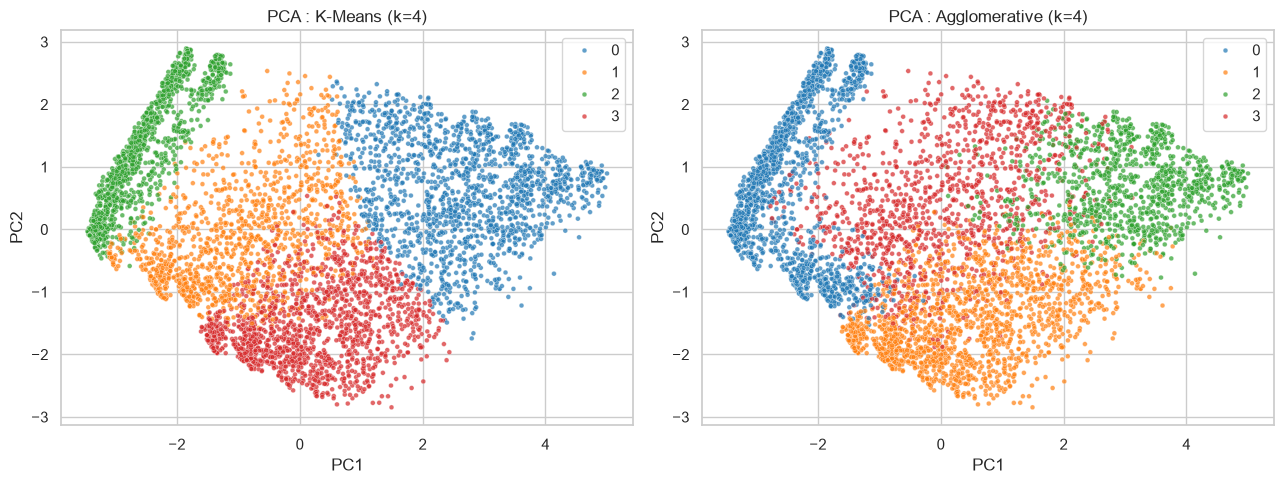

Variables qui définissent PC1 :
{'n_services': 0.44, 'TotalCharges': 0.42, 'MonthlyCharges': 0.42, 'avg_charge': 0.42, 'tenure': 0.3}
Variables qui définissent PC2 :
{'tenure': 0.56, 'MonthlyCharges': 0.33, 'avg_charge': 0.33, 'Contract_Month-to-month': 0.28, 'TotalCharges': 0.27}


In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z_train)
P = pca.transform(Z_train)
print("Variance expliquée :", pca.explained_variance_ratio_.round(3), "| total :", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, labs, title in zip(axes, [labels_km, labels_ag], ["K-Means (k=4)", "Agglomerative (k=4)"]):
    sns.scatterplot(x=P[:, 0], y=P[:, 1], hue=labs, palette="tab10", s=12, alpha=0.7, ax=ax, legend="full")
    ax.set_title(f"PCA : {title}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_.T, index=Z_train.columns, columns=["PC1", "PC2"])
print("Variables qui définissent PC1 :"); print(loadings["PC1"].abs().sort_values(ascending=False).head(5).round(2).to_dict())
print("Variables qui définissent PC2 :"); print(loadings["PC2"].abs().sort_values(ascending=False).head(5).round(2).to_dict())

**Lecture :** les deux axes expliquent environ 60 % de la variance. PC1 correspond surtout au **niveau de consommation** (nombre de services et montant des factures), PC2 surtout à l'**ancienneté**. Les clusters s'organisent le long de ces axes, avec un chevauchement aux frontières, cohérent avec la silhouette modérée. Les deux algorithmes dessinent une carte similaire.

## 8. Interprétation des profils

On décrit chaque cluster avec les variables **d'origine** (avant standardisation), plus lisibles. Le taux de churn est calculé **après coup** pour interpréter : il n'a servi à construire aucun cluster.

In [8]:
prof = X_train.copy()
prof["cluster"] = labels_km
prof["churn"] = y_train.values

profile = prof.groupby("cluster").agg(
    effectif=("tenure", "size"),
    tenure_moy=("tenure", "mean"),
    facture_mensuelle=("MonthlyCharges", "mean"),
    n_services=("n_services", "mean"),
    senior=("SeniorCitizen", "mean"),
    partenaire=("Partner", "mean"),
    fibre=("InternetService", lambda s: (s == "Fiber optic").mean()),
    sans_internet=("InternetService", lambda s: (s == "No").mean()),
    contrat_mensuel=("Contract", lambda s: (s == "Month-to-month").mean()),
    paiement_cheque_elec=("PaymentMethod", lambda s: (s == "Electronic check").mean()),
    taux_churn=("churn", "mean"),
)
profile.insert(1, "part_clients", profile["effectif"] / profile["effectif"].sum())

# Noms de segments déduits de règles sur le profil (robuste à la numérotation des clusters)
def name_cluster(r):
    if r["sans_internet"] > 0.8: return "Téléphone seul, économiques"
    if r["fibre"] > 0.8:         return "Fibre récents, à risque"
    if r["tenure_moy"] > 45:     return "Fidèles premium"
    return "DSL intermédiaires"

profile["segment"] = profile.apply(name_cluster, axis=1)
cluster_names = profile["segment"].to_dict()
profile.set_index("segment").round(2)

,effectif,part_clients,tenure_moy,facture_mensuelle,n_services,senior,partenaire,fibre,sans_internet,contrat_mensuel,paiement_cheque_elec,taux_churn
segment,,,,,,,,,,,,
Fidèles premium,1586,0.28,59.56,91.83,6.81,0.20,0.70,0.64,0.00,0.20,0.27,0.14
DSL intermédiaires,1309,0.23,21.34,50.99,3.71,0.11,0.36,0.00,0.00,0.69,0.33,0.25
"Téléphone seul, économiques",1241,0.22,30.01,21.20,1.23,0.03,0.48,0.00,0.98,0.36,0.07,0.07
"Fibre récents, à risque",1498,0.27,15.62,84.86,4.21,0.28,0.36,0.98,0.00,0.96,0.63,0.57


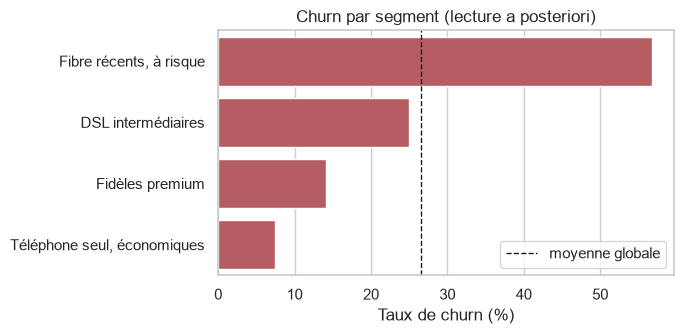

In [9]:
order = profile.sort_values("taux_churn", ascending=False)
plt.figure(figsize=(7, 3.5))
sns.barplot(x=order["taux_churn"] * 100, y=order["segment"], color="#C44E52")
plt.axvline(y_train.mean() * 100, color="k", ls="--", lw=1, label="moyenne globale")
plt.xlabel("Taux de churn (%)"); plt.ylabel(""); plt.legend(); plt.title("Churn par segment (lecture a posteriori)")
plt.tight_layout(); plt.show()

**Les 4 segments :**

| Segment | Profil | Churn |
|---|---|---|
| **Fidèles premium** | Environ 5 ans d'ancienneté, facture élevée (~92 $), ~7 services, majorité sous contrat long | faible (~14 %) |
| **DSL intermédiaires** | Ancienneté moyenne (~21 mois), internet DSL, facture modérée (~51 $) | moyen (~25 %) |
| **Téléphone seul, économiques** | Presque tous sans internet, facture très basse (~21 $), 1 service en moyenne | très faible (~7 %) |
| **Fibre récents, à risque** | Fibre à ~98 %, ancienneté courte (~16 mois), facture élevée (~85 $), quasi tous en contrat mensuel, souvent paiement par chèque électronique | très élevé (~57 %) |

**À retenir :** le segment à risque a un churn environ **7 à 8 fois supérieur** à celui du segment économique (57 % contre 7 % sur le train, 55 % contre 8 % sur le test), alors que `Churn` n'a pas servi à former les clusters. La segmentation capte donc des signaux liés au churn : on le vérifiera en J7 en ajoutant `cluster` au modèle. Cela confirme aussi les constats de l'EDA (contrat mensuel, fibre, ancienneté courte).

## 9. Attribution des clusters au jeu de test

Le test reçoit ses clusters avec `kmeans.predict` : le modèle ajusté sur le train n'est **pas** ré-entraîné.

In [10]:
clusters_train = kmeans.predict(Z_train)
clusters_test  = kmeans.predict(Z_test)
assert (clusters_train == labels_km).all()

stab = pd.DataFrame({
    "% train": pd.Series(clusters_train).value_counts(normalize=True).sort_index() * 100,
    "% test":  pd.Series(clusters_test).value_counts(normalize=True).sort_index() * 100,
    "churn % test": pd.Series(y_test.values).groupby(clusters_test).mean() * 100,
}).round(1)
stab.index = [cluster_names[i] for i in stab.index]
stab

,% train,% test,churn % test
Fidèles premium,28.2,25.8,12.4
DSL intermédiaires,23.2,24.2,27.0
"Téléphone seul, économiques",22.0,22.5,7.9
"Fibre récents, à risque",26.6,27.5,54.6


**Lecture :** la répartition en clusters est proche entre train et test, et l'ordre des taux de churn est conservé : la segmentation est **stable** sur des clients non vus.

## 10. Sauvegarde

In [11]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(pre, "../models/preprocessor.joblib")
joblib.dump(kmeans, "../models/kmeans.joblib")

train_out = X_train.assign(cluster=clusters_train, **{TARGET: y_train.values})
test_out  = X_test.assign(cluster=clusters_test,  **{TARGET: y_test.values})
train_out.to_csv("../data/processed/train_with_clusters.csv", index=False)
test_out.to_csv("../data/processed/test_with_clusters.csv", index=False)
print("train_with_clusters :", train_out.shape, "| test_with_clusters :", test_out.shape)

# Test de relecture
km_check = joblib.load("../models/kmeans.joblib")
assert (km_check.predict(Z_test) == clusters_test).all()
print("Rechargement OK")

train_with_clusters : (5634, 24) | test_with_clusters : (1409, 24)
Rechargement OK


## 11. Synthèse

- **Données** : 32 colonnes issues du preprocessor, sans `Churn`, ajustées sur le train.
- **K-Means, k = 4** : choisi pour la lisibilité métier (silhouette maximale à k = 2, mais trop grossier).
- **Comparaison** : Agglomerative donne des scores proches, un peu inférieurs ; DBSCAN n'est pas adapté.
- **Qualité** : silhouette ≈ 0,2, structure réelle mais chevauchante.
- **Profils** : 4 segments clairs, de 7 % à 57 % de churn.
- **Sorties** : `models/kmeans.joblib`, `models/preprocessor.joblib`, `data/processed/train_with_clusters.csv`, `test_with_clusters.csv`.

**Suite (J6–J7)** : classification avec et sans la variable `cluster`.

*Remarque :* K-Means est ajusté sur tout le train. Pour la validation croisée de J8, on pourra placer K-Means dans le Pipeline afin d'éviter une légère fuite entre les plis.